# Introduction to Transpilation

**Transpilation** is the process of rewriting a given input circuit to match the topology of a specific quantum device, and optimize the circuit instructions for execution on noisy quantum computers. Transpilation then transforms the circuit such that only instructions available on a chosen backend are used, and optimizes those instructions to minimize the effects of noise. It is designed for modularity and extensibility.

**Transpiler passes**: New circuit transformation done by transpiler and these individual passes are combined, greatly reducing the depth and complexity of quantum circuits.

Which passes are chained together and in which order has a major effect on the final outcome. This pipeline is determined by the **PassManager** and **StagedPassManager** objects. 

**StagedPassManager**: The StagedPassManager orchestrates the execution of one or more PassManagers and determines the order in which they are executed, while the PassManager object is merely a collection of one or more passes. Think of the StagedPassManager as the conductor in an orchestra, the PassManagers as the different instrument sections, and the Pass objects as the individual musicians

Use **generate_preset_pass_manager** function to generate a staged pass manager with reasonable defaults.

**Instruction Set Architecture**: The transpiler is designed to transform the instructions contained in a given QuantumCircuit to obey the Instruction Set Architecture (ISA) of a particular backend. Circuits obeying the ISA consist only of instructions that are supported by the backend's Target, such as the hardware's available basis gates, measurements, resets, and control flow operations, and comply with the constraints specified by the connectivity of the hardware, that is, the target's CouplingMap. When submitting a job to an IBM Quantum® backend, the circuits must adhere to the backend's ISA.

### Transpiler Stages

Qiskit's prebuilt transpiler pipeline consists of six fundamental stages:

**init** - This pass runs any initial passes that are required before the circuit can be embedded. This typically involves unrolling custom instructions and converting the circuit to all single- and two-qubit gates. By default, this validates the circuit instructions and translates multi-qubit gates into single- and two-qubit gates.

**layout** - This pass applies a layout, mapping the virtual qubits in your circuit to the QPU's physical qubits.

**routing** - This pass runs after a layout has been applied and will inject gates (that is, SWAPs) in the original circuit to make it compatible with the QPU's connectivity (coupling map).

**translation** - This pass translates the gates in the circuit to the QPU's basis set of instructions.

**optimization** - This pass runs an optimization loop to find more efficient decompositions of the quantum circuit until a condition is met (such as a fixed depth).

**scheduling** - This stage is for any hardware-aware scheduling passes. If the user specifies a scheduling method, this stage accounts for all idle time in the circuit.

The Pass Managers are pluggable and extensible. Users can replace the implementation of a single stage on the fly by:
- Substituting stage with custom PassManager object
- Modifying stage in-place

This allows to reuse a prebuilt pipeline and customize a small component. **pip install qiskit-qubit-reuse** is a reuse plugin. The recommended way to transpile a circuit is to create a preset staged pass manager and then run that pass manager on the circuit, as described in Transpile with pass managers. However, a simpler but less customizable alternative is to use the transpile function. This function accepts the circuit directly as an argument. As with generate_preset_pass_manager, the specific transpiler passes used depend on the arguments, such as optimization_level, passed to transpile. In fact, internally the transpile function calls generate_preset_pass_manager to create a preset staged pass manager and runs it on the circuit.

### Init Stage

#### Phase 1: Decomposing Larger Gates
Goal: Decompose larger gates or operations (those involving three or more qubits) into one or two qubit gates 

Purpose: Most layout algorithms represent the circuit as a graph. Since a graph can't easily represent a gate with more than two qubits (which would be a hypergraph), these larger operations must be lowered first to enable the layout stage 

#### Phase 2: Logical Optimizations
Goal: Perform optimizations that are independent of specific hardware constraints 

##### Key Passes:

**RemoveIdentityEquivalent**: Remove gates that are equivalent to an identity.

**RemoveDiagonalBeforeMeasure**: Remove a diagonal gate, such as RZ, that occurs immediately before a measure. This doesn't impact the result of the measurement and can be removed.

**InverseCancellation**: Remove gates that are inverse pairs, such as two CX gates.

**CommutativeCancellation**: Remove any inverse pairs found by reordering commutative operations (also run in the optimization stage).

**ConsolidateBlocks**: Consolidate blocks of 2q operations into UnitaryGate (also run in the optimization stage).

**Split2QUnitaries**: Any UnitaryGates that are composed of a product of two single qubit gates will be decomposed into a single qubit UnitaryGate on each qubit.

**Elide Permutations**: Swaps "virtual" qubits instead of inserting physical swap gates. This is only possible in the init stage before physical qubits have been assigned 

### Layout Stage

The choice of mapping is extremely important for minimizing the number of SWAP operations needed to map the input circuit onto the device topology and ensure the most well-calibrated qubits are used. Due to the importance of this stage, the preset pass managers try a few different methods to find the best layout. Typically this involves two steps: first, try to find a "perfect" layout (a layout that does not require any SWAP operations), and then, a heuristic pass that tries to find the best layout to use if a perfect layout cannot be found. There are two Passes typically used for this first step:

**TrivialLayout**: Naively maps each virtual qubit to the same numbered physical qubit on the device (i.e., [0,1,1,3] -> [0,1,1,3]). This is historical behavior only used in optimzation_level=1 to try to find a perfect layout. If it fails, VF2Layout is tried next.

**VF2Layout**: This is an AnalysisPass that selects an ideal layout by treating this stage as a subgraph isomorphism problem, solved by the VF2++ algorithm. If more than one layout is found, a scoring heuristic is run to select the mapping with the lowest average error.

Then for the heuristic stage, two passes are used by default:

**DenseLayout**: Finds the sub-graph of the device with the greatest connectivity and that has the same number of qubits as the circuit (used for optimization level 1 if there are control flow operations (such as IfElseOp) present in the circuit).

**SabreLayout**: This pass selects a layout by starting from an initial random layout and repeatedly running the SabreSwap algorithm. This pass is only used in optimization levels 1, 2, and 3 if a perfect layout isn't found via the VF2Layout pass.

<img src="layout.png" width="800" align="center">

**VF2Layout Pass**

- Builds a graph from 2-qubit interactions in the circuit

- Searches for isomorphic subgraphs in the target's connectivity graph

- If a subgraph is found, a layout without swaps can be used

- After a layout is found, it searches for additional layouts

- Picks the layout with the lowest error rate

- It leverages the rustworkx's VF2 algorithm implementation to efficiently search for an isomorphism

**SabreLayout Pass**

- Run if VF2Layout doesn't find a layout

- Based on SABRE (SWAP-based BidiREctional) algorithm:

- Starts with an initial random guess

- Routes circuit by swapping qubits in the layout instead of inserting swap gates

- If fully routed, reverses edge direction in the DAG and re-routes

- Repeats multiple times to minimize swap count

### Routing Stage

In order to implement a two-qubit gate between qubits that are not directly connected on a quantum device, one or more SWAP gates must be inserted into the circuit to move the qubit states around until they are adjacent on the device gate map. Each SWAP gate represents an expensive and noisy operation to perform. Thus, finding the minimum number of SWAP gates needed to map a circuit onto a given device is an important step in the transpilation process. For efficiency, this stage is typically computed alongside the Layout stage by default, but they are logically distinct from one another. The Layout stage selects the hardware qubits to be used, while the Routing stage inserts the appropriate amount of SWAP gates in order to execute the circuits using the selected layout.

However, finding the optimal SWAP mapping is hard. In fact, it is an NP-hard problem, and is thus prohibitively expensive to compute for all but the smallest quantum devices and input circuits. To work around this, Qiskit uses a stochastic heuristic algorithm called **SabreSwap** to compute a good, but not necessarily optimal, SWAP mapping. The use of a stochastic method means that the circuits generated are not guaranteed to be the same over repeated runs. Indeed, running the same circuit repeatedly results in a distribution of circuit depths and gate counts at the output. It is for this reason that many users choose to run the routing function (or the entire StagedPassManager) many times and select the lowest-depth circuits from the distribution of outputs. We rerun the layout with **VF2PostLayout** after swap insertion to search for a better layout.

**VF2PostLayout Pass**

- Builds a graph from 2-qubit interactions in the circuit
- Searches for isomorphic subgraphs in the target's connectivity graph
- Difference with VF2Layout: the pass is run post-routing, this guarantees at least one isomorphic subgraph
- Again, the pass searches for additional layouts and picks the layout with the lowest error rate

### Translation Stage

Most of the quantum devices only natively support a handful of quantum gate and non-gate operations. These native gates are part of the definition of a target's ISA and this stage of the preset PassManagers translates (or unrolls) the gates specified in a circuit to the native basis gates of a specified backend. This is an important step, as it allows the circuit to be executed by the backend, but typically leads to an increase in the depth and number of gates.

**Case 1**: If a SWAP gate is not a native gate to the target backend, this requires three CNOT gates:

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
backend.name

'ibm_fez'

native gates:['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']


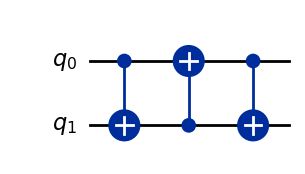

In [4]:
from qiskit import QuantumCircuit

print("native gates:" + str(sorted(backend.operation_names)))
qc = QuantumCircuit(2)
qc.swap(0, 1)
qc.decompose().draw("mpl")

As a product of three CNOT gates, a SWAP is an expensive operation to perform on noisy quantum devices. However, such operations are usually necessary for embedding a circuit into the limited gate connectivities of many devices. Thus, minimizing the number of SWAP gates in a circuit is a primary goal in the transpilation process.

**Case 2**: A Toffoli, or controlled-controlled-not gate (ccx), is a three-qubit gate. Given that our basis gate set includes only single- and two-qubit gates, this operation must be decomposed. However, it is quite costly:

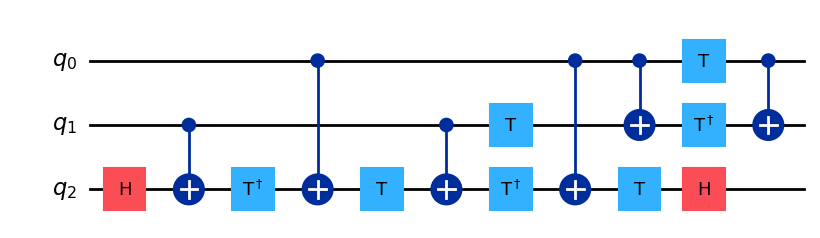

In [5]:
qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)
qc.decompose().draw("mpl")

In the Translation Stage of the Qiskit transpiler, two specific passes handle the conversion of abstract mathematical objects into actual quantum circuits:

**1. HighLevelSynthesis Pass**

This is a pluggable synthesis pass designed for high-level objects. Instead of manually decomposing every gate, this pass scans the Directed Acyclic Graph (DAG) for gates that are not supported by the target hardware but have an "installed plugin" available.

How it works: It calls specific plugins to synthesize high-level abstract objects into equivalent circuits based on the target device's constraints.

Supported Gates: It handles objects like Clifford Tableaus, LinearFunctions, PermutationGates, and PauliEvolutionGates (used for Hamiltonian simulations).

Flexibility: Users can write their own custom synthesis methods for new types of gates and register them as plugins.

**2. UnitarySynthesis Pass**

This is a specialized pass dedicated to synthesizing UnitaryGates—gates defined solely by their unitary matrix.

Goal: It takes a raw matrix (the mathematical representation of what the gate does) and finds the most efficient sequence of hardware-native gates to replicate that matrix.

Built-in Plugins: Qiskit includes three built-in plugins for this pass, including methods for approximation to help reduce circuit depth.

Optimization: In higher optimization levels (Level 3), this pass is run inside a loop to constantly re-synthesize and shrink blocks of gates to reduce error.

### Optimization Stage

This stage centers around decomposing quantum circuits into the basis gate set of the target device, and must fight against the increased depth from the layout and routing stages. Fortunately, there are many routines for optimizing circuits by either combining or eliminating gates. In some cases, these methods are so effective that the output circuits have lower depth than the inputs, even after layout and routing to the hardware topology. In other cases, not much can be done, and the computation may be difficult to perform on noisy devices. This stage is where the various optimization levels begin to differ.

- For optimization_level=1, this stage prepares Optimize1qGatesDecomposition and CXCancellation, which combine chains of single-qubit gates and cancel any back-to-back CNOT gates.

- For optimization_level=2, this stage uses the CommutativeCancellation pass instead of CXCancellation, which removes redundant gates by exploiting commutation relations.

- For optimization_level=3, this stage prepares the following passes:

**Collect2qBlocks**: Traverses the DAG efficiently. For each CNOT, it collects ancestors and predecessors until a branch is found. These form a 2q block.

**ConsolidateBlocks**:

**UnitarySynthesis**:

**Optimize1qGateDecomposition**: finds sequences of single qubit gates and optimizes them

**CommutativeCancellation**: It finds the two consecutive gates that are commutative and swaps them and if after swapping any of them lead to identity, it removed those gates.

Additionally, this stage also executes a few final checks to make sure that all instructions in the circuit are composed of the basis gates available on the target backend.

### Scheduling Stage

This last stage is only run if it is explicitly called for (similar to the Init stage) and does not run by default. The scheduling stage is typically used once the circuit has been translated to the target basis, mapped to the device, and optimized. These passes focus on accounting for all the idle time in a circuit. At a high level, the scheduling pass can be thought of as explicitly inserting delay instructions to account for the idle time between gate executions and to inspect how long the circuit will be running on the backend.

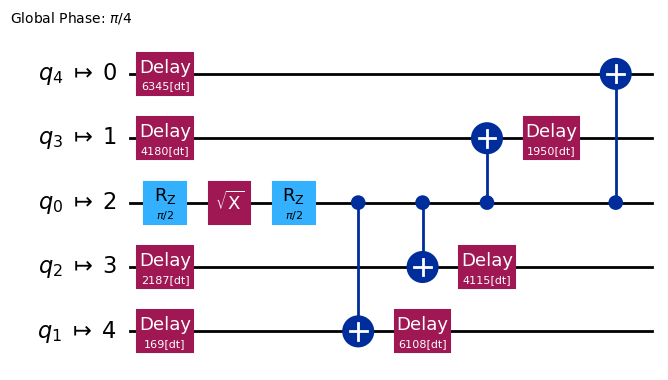

In [9]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

ghz = QuantumCircuit(5)
ghz.h(0)
ghz.cx(0, range(1, 5))


# Use fake backend
backend = GenericBackendV2(5)

# Run with optimization level 3 and 'asap' scheduling pass
pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    scheduling_method="asap",
    seed_transpiler=1234,
)


circ = pass_manager.run(ghz)
circ.draw(output="mpl", idle_wires=False)

### Staged pass manager

A pass manager is an object that stores a list of transpiler passes and can execute them on a circuit. Create a pass manager by initializing a PassManager with a list of transpiler passes. To run the transpilation on a circuit, call the run method with a circuit as input.

A staged pass manager is a special kind of pass manager that represents a level of abstraction above that of a normal pass manager. While a normal pass manager is composed of several transpiler passes, a staged pass manager is composed of several pass managers. This is a useful abstraction because transpilation typically happens in discrete stages.

Each stage - init, layout, routing, optimization, translation, scheduling are represented by a pass manager.

To create a preset staged pass manager with reasonable defaults, use the generate_preset_pass_manager function.

In [10]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

backend = FakeSherbrooke()
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)

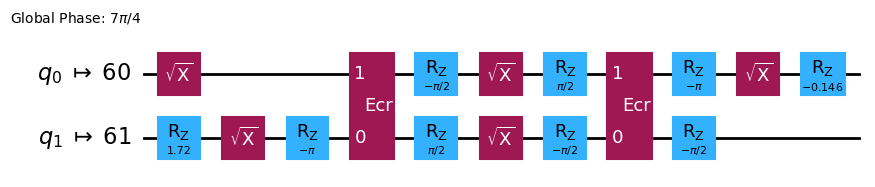

In [12]:
from qiskit import QuantumRegister, QuantumCircuit

# Create a circuit
qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)
a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a)

# Transpile it by calling the run method of the pass manager
transpiled = pass_manager.run(circuit)

# Draw it, excluding idle qubits from the diagram
transpiled.draw("mpl", idle_wires=False)

### Create your own pass manager

If the preset pass managers don't fulfill your needs, customize transpilation by creating (staged) pass managers or even transpilation passes.

The qiskit.transpiler.passes module includes many transpiler passes that can be used to create pass managers. To create a pass manager, initialize a PassManager with a list of passes. For example, the following code creates a transpiler pass that merges adjacent two-qubit gates and then synthesizes them into a basis of 
R
y
R 
y
​
 , 
R
z
R 
z
​
 , and 
R
x
x
R 
xx
​
 , gates.

In [13]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    Collect2qBlocks,
    ConsolidateBlocks,
    UnitarySynthesis,
)

basis_gates = ["rx", "ry", "rxx"]
translate = PassManager(
    [
        Collect2qBlocks(),
        ConsolidateBlocks(basis_gates=basis_gates),
        UnitarySynthesis(basis_gates),
    ]
)

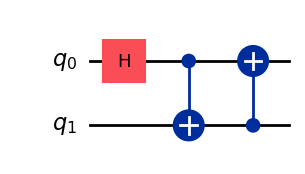

In [14]:
from qiskit import QuantumRegister, QuantumCircuit

qubits = QuantumRegister(2, name="q")
circuit = QuantumCircuit(qubits)

a, b = qubits
circuit.h(a)
circuit.cx(a, b)
circuit.cx(b, a)

circuit.draw("mpl")

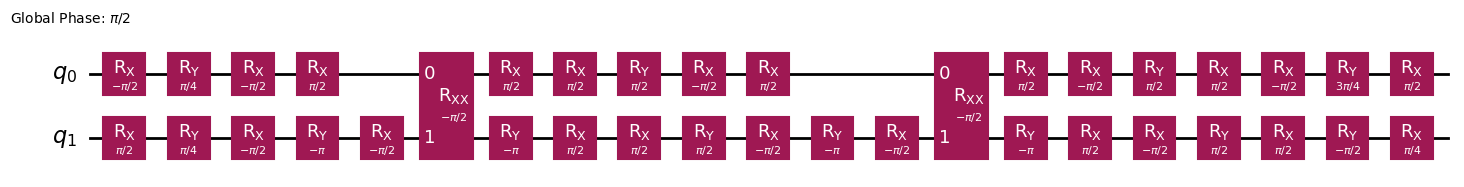

In [15]:
translated = translate.run(circuit)
translated.draw("mpl")

### Create a staged pass manager

A StagedPassManager is a pass manager that is composed of individual stages, where each stage is defined by a PassManager instance. You can create a StagedPassManager by specifying the desired stages. For example, the following code creates a staged pass manager with two stages, init and translation. The translation stage is defined by the pass manager that was created previously.

In [16]:
from qiskit.transpiler import PassManager, StagedPassManager
from qiskit.transpiler.passes import UnitarySynthesis, Unroll3qOrMore

basis_gates = ["rx", "ry", "rxx"]
init = PassManager(
    [UnitarySynthesis(basis_gates, min_qubits=3), Unroll3qOrMore()]
)
staged_pm = StagedPassManager(
    stages=["init", "translation"], init=init, translation=translate
)

There is no limit on the number of stages you can put in a staged pass manager.

Another useful way to create a staged pass manager is to begin with a preset staged pass manager and then swap out some of the stages. For example, the following code generates a preset pass manager with optimization level 3, and then specifies a custom pre_layout stage.

In [17]:
import numpy as np
from qiskit.circuit.library import HGate, PhaseGate, RXGate, TdgGate, TGate
from qiskit.transpiler.passes import InverseCancellation

pass_manager = generate_preset_pass_manager(3, backend)
inverse_gate_list = [
    HGate(),
    (RXGate(np.pi / 4), RXGate(-np.pi / 4)),
    (PhaseGate(np.pi / 4), PhaseGate(-np.pi / 4)),
    (TGate(), TdgGate()),
]
logical_opt = PassManager(
    [
        InverseCancellation(inverse_gate_list),
    ]
)

# Add pre-layout stage to run extra logical optimization
pass_manager.pre_layout = logical_opt

**Note that the same setting could improve the results of one circuit while hindering another. Be sure to inspect the resulting transpiled circuits before running on actual hardware.**

In [18]:
# Create circuit to test transpiler on
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import grover_operator, DiagonalGate

# Use Statevector object to calculate the ideal output
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit.transpiler import PassManager

from qiskit.circuit.library import XGate
from qiskit.quantum_info import hellinger_fidelity

Hellinger fidelity is a metric used to compare two probability distributions.

While "state fidelity" (like Uhlmann fidelity) measures how similar two quantum wavefunctions or density matrices are in their complex vector space, Hellinger fidelity is used for classical measurement outcomes (bitstring counts).

When you run a quantum circuit on real hardware, you don't get the full statevector; you get counts (e.g., {'00': 510, '11': 490}). Hellinger fidelity allows you to compare these experimental results against an ideal theoretical distribution to see how well the hardware performed.

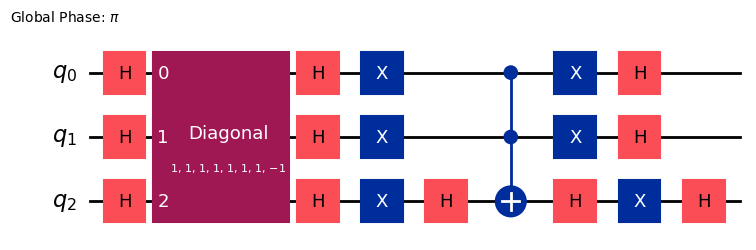

In [20]:
# By applying this DiagonalGate, you are essentially telling the quantum computer: "I am looking for the state 111. When you see it, flip 
# its phase so I can use interference to amplify its probability later."
oracle = DiagonalGate([1] * 7 + [-1])
qc = QuantumCircuit(3)
qc.h([0, 1, 2])
qc = qc.compose(grover_operator(oracle))

qc.draw(output="mpl", style="iqp")

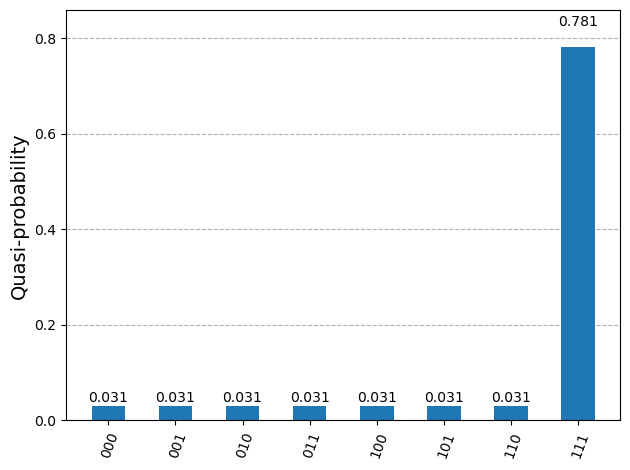

In [21]:
ideal_distribution = Statevector.from_instruction(qc).probabilities_dict()

plot_histogram(ideal_distribution)

In [22]:
# Use Qiskit Runtime to run jobs on hardware
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler,
)

In [23]:
# Select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

'ibm_fez'

In [24]:
# Need to add measurements to the circuit
qc.measure_all()

# Find the correct two-qubit gate
twoQ_gates = set(["ecr", "cz", "cx"])
for gate in backend.basis_gates:
    if gate in twoQ_gates:
        twoQ_gate = gate

circuits = []
for optimization_level in [0, 3]:
    pm = generate_preset_pass_manager(
        optimization_level, backend=backend, seed_transpiler=0
    )
    t_qc = pm.run(qc)
    print(
        f"Two-qubit gates (optimization_level={optimization_level}): ",
        t_qc.count_ops()[twoQ_gate],
    )
    circuits.append(t_qc)

Two-qubit gates (optimization_level=0):  21
Two-qubit gates (optimization_level=3):  12


In [25]:
# Need to add measurements to the circuit
qc.measure_all()

# Find the correct two-qubit gate
twoQ_gates = set(["ecr", "cz", "cx"])
for gate in backend.basis_gates:
    if gate in twoQ_gates:
        twoQ_gate = gate

circuits = []
for optimization_level in [0, 1,2,3]:
    pm = generate_preset_pass_manager(
        optimization_level, backend=backend, seed_transpiler=0
    )
    t_qc = pm.run(qc)
    print(
        f"Two-qubit gates (optimization_level={optimization_level}): ",
        t_qc.count_ops()[twoQ_gate],
    )
    circuits.append(t_qc)

Two-qubit gates (optimization_level=0):  21
Two-qubit gates (optimization_level=1):  18
Two-qubit gates (optimization_level=2):  12
Two-qubit gates (optimization_level=3):  12


In [26]:
from qiskit_ibm_runtime.transpiler.passes.scheduling import (
    ASAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

# Get gate durations so the transpiler knows how long each operation takes
durations = backend.target.durations()

# This is the sequence we'll apply to idling qubits
dd_sequence = [XGate(), XGate()]

# Run scheduling and dynamic decoupling passes on circuit
pm = PassManager(
    [
        ASAPScheduleAnalysis(durations),
        PadDynamicalDecoupling(durations, dd_sequence),
    ]
)
circ_dd = pm.run(circuits[1])

# Add this new circuit to our list
circuits.append(circ_dd)

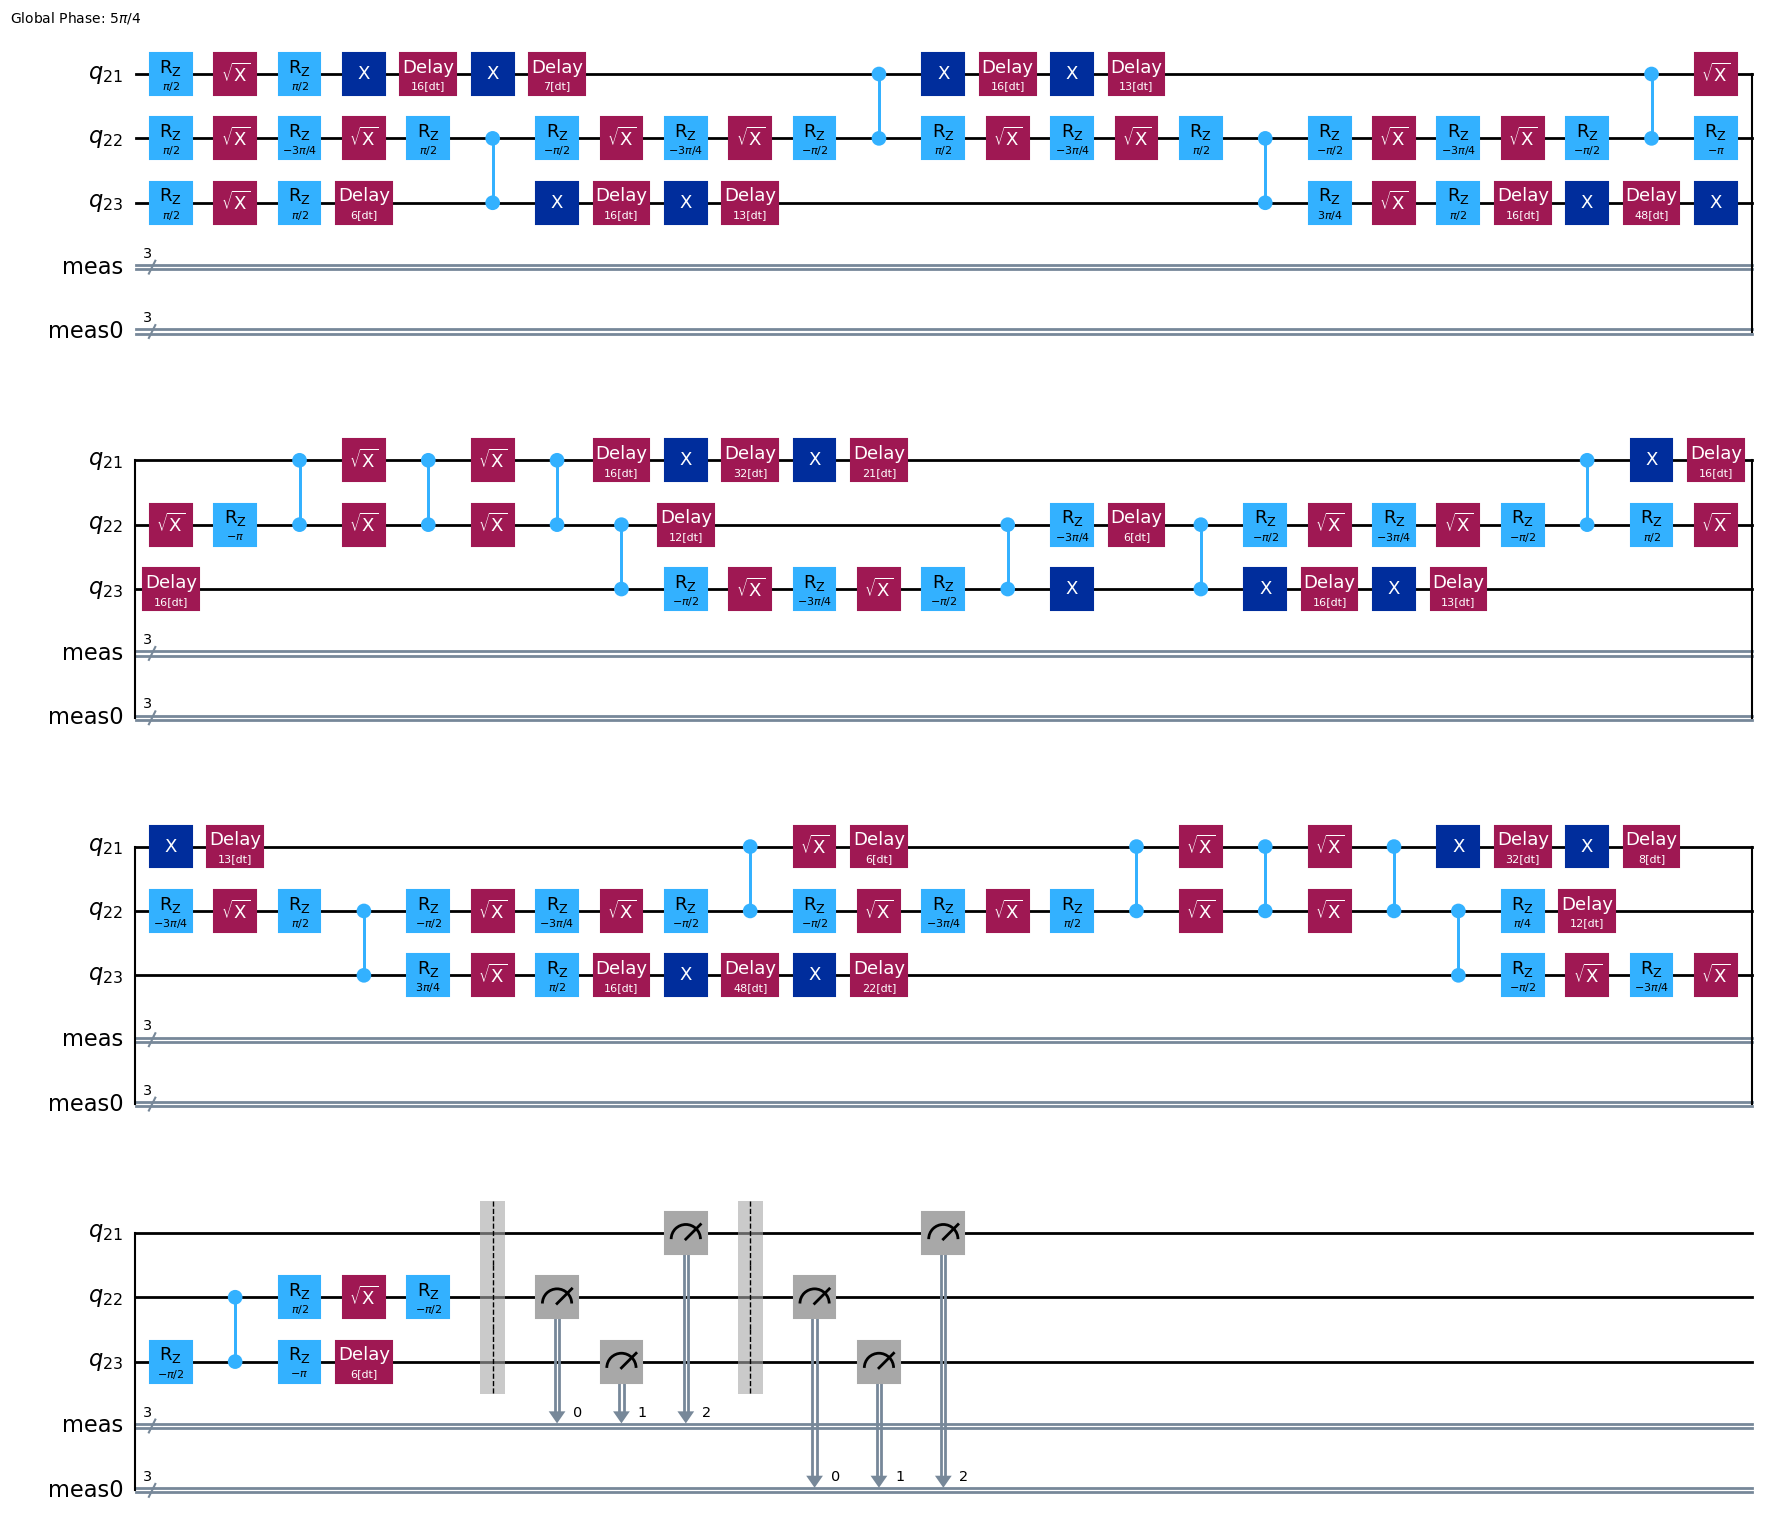

In [27]:
circ_dd.draw(output="mpl", style="iqp", idle_wires=False)

In [28]:
sampler = Sampler(backend)
job = sampler.run(
    [(circuit) for circuit in circuits],  # sample all three circuits
    shots=8000,
)
result = job.result()

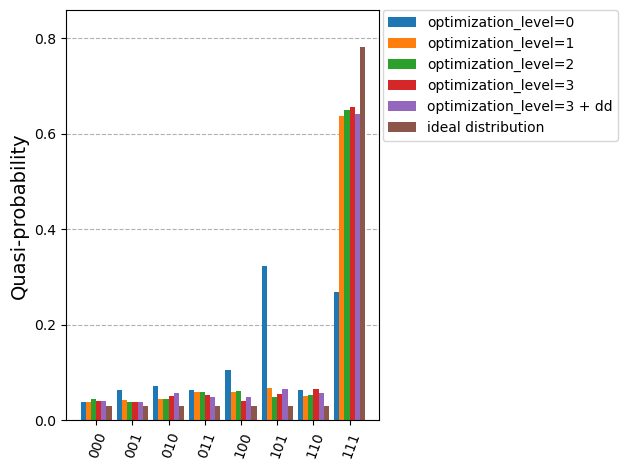

In [30]:
binary_prob = [
    {
        k: v / res.data.meas.num_shots
        for k, v in res.data.meas.get_counts().items()
    }
    for res in result
]
plot_histogram(
    binary_prob + [ideal_distribution],
    bar_labels=False,
    legend=[
        "optimization_level=0",
        "optimization_level=1",
        "optimization_level=2",
        "optimization_level=3",
        "optimization_level=3 + dd",
        "ideal distribution",
    ],
)

In [31]:
# Hellinger fidelity between each set of results and the ideal distribution (higher is better, and 1 is perfect fidelity).
for prob in binary_prob:
    print(f"{hellinger_fidelity(prob, ideal_distribution):.3f}")

0.693
0.972
0.977
0.978
0.974


In [33]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

backend = FakeSherbrooke()

target = backend.target
basis_gates = list(target.operation_names)
print(basis_gates)

['delay', 'if_else', 'id', 'sx', 'reset', 'for_loop', 'switch_case', 'ecr', 'rz', 'x', 'measure']
